
SEASONAL ANALYSIS: ORIGINAL vs AB vs STS vs COM

Best Original Product by Season:
  Winter: GLEAM (22.6% of time)
  Spring: GLEAM (21.0% of time)
  Summer: GLDAS (18.4% of time)
  Autumn: GLEAM (18.5% of time)

Best AB Product by Season:
  Winter: GLEAM (19.0% of time)
  Spring: LSA (23.8% of time)
  Summer: LSA (22.9% of time)
  Autumn: LSA (19.0% of time)

STS Performance by Season:
  Winter: 20.9% best, MAE = 1.05 mm/8d
  Spring: 12.7% best, MAE = 2.24 mm/8d
  Summer: 16.1% best, MAE = 2.38 mm/8d
  Autumn: 18.2% best, MAE = 1.20 mm/8d

COM Performance by Season:
  Winter: 26.0% best, MAE = 0.72 mm/8d
  Spring: 26.6% best, MAE = 1.28 mm/8d
  Summer: 28.6% best, MAE = 1.49 mm/8d
  Autumn: 29.8% best, MAE = 0.70 mm/8d


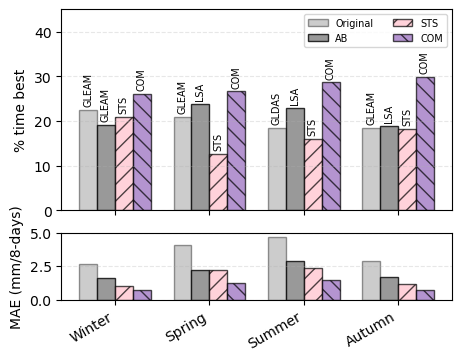


✓ Analysis complete!
✓ Figure saved as: ET4I_Seasonal.png

SEASONAL COMPARISON SUMMARY

Season     Orig       AB         STS        COM        Best Method    
----------------------------------------------------------------------
Winter     2.70       1.64       1.05       0.72       COM            
Spring     4.05       2.20       2.24       1.28       COM            
Summer     4.72       2.92       2.38       1.49       COM            
Autumn     2.90       1.70       1.20       0.70       COM            

----------------------------------------------------------------------
Average    3.60       2.12       1.72       1.05      

IMPROVEMENT FROM ORIGINAL (%)

Season     AB              STS             COM            
------------------------------------------------------------
Winter     39.5          % 61.3          % 73.3          %
Spring     45.7          % 44.9          % 68.5          %
Summer     38.1          % 49.7          % 68.5          %
Autumn     41.3          % 58

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# === Load Data ===
STN_DATA = xr.open_dataarray("../DATA/STN_DATA.nc")
STN_AB = xr.open_dataarray("../DATA/STN_AB.nc")
STN_STS = xr.open_dataarray("../DATA/STN_STS.nc")
STN_COM = xr.open_dataarray("../DATA/STN_COM.nc")

# === Settings ===
seasons = {'Winter': [12, 1, 2], 'Spring': [3, 4, 5], 'Summer': [6, 7, 8], 'Autumn': [9, 10, 11]}
original_color = 'gray'
ab_color = 'gray'
sts_color = 'pink'
com_color = '#9467bd'

# === Functions ===

def compute_best_product_counts(data, pm_reference=None):
    results = {}
    for season_name, season_months in seasons.items():
        month_mask = data['datetime.month'].isin(season_months)
        season_data = data.where(month_mask, drop=True)

        pm_data = pm_reference.where(month_mask, drop=True).sel(Product='PM') if pm_reference is not None else season_data.sel(Product='PM')

        stations = season_data.Station.values
        products = season_data.Product.values
        n_time = season_data.sizes['datetime']
        counts = {p: [] for p in products if p not in ['PM', 'TH']}

        for stn in stations:
            stn_data = season_data.sel(Station=stn)
            pm_stn = pm_data.sel(Station=stn)
            errors = abs(stn_data.drop_sel(Product=['PM', 'TH'], errors='ignore') - pm_stn)
            best = errors.argmin(dim='Product')
            best_prod = errors.Product.values[best.values]
            stn_counts = {p: np.sum(best_prod == p) / n_time * 100 for p in counts}
            for p in counts:
                counts[p].append(stn_counts[p])

        avg_percentages = {p: np.mean(counts[p]) for p in counts}
        top_1 = sorted(avg_percentages.items(), key=lambda x: x[1], reverse=True)[:1]
        results[season_name] = top_1
    return results

def compute_merged_performance(data, merged_data, pm_reference=None):
    """
    Compute merged product performance: percentage of time it's the best, and average error.
    Works for STS and COM.
    """
    results = {}
    for season_name, season_months in seasons.items():
        month_mask = data['datetime.month'].isin(season_months)
        season_data = data.where(month_mask, drop=True)
        season_merged = merged_data.where(month_mask, drop=True)

        pm_data = pm_reference.where(month_mask, drop=True).sel(Product='PM') if pm_reference is not None else season_data.sel(Product='PM')

        stations = season_data.Station.values
        n_time = season_data.sizes['datetime']
        merged_counts, merged_errors = [], []

        for stn in stations:
            pm_stn = pm_data.sel(Station=stn)
            merged_stn = season_merged.sel(Station=stn)
            merged_error = abs(merged_stn - pm_stn)
            merged_errors.append(float(merged_error.mean()))

            stn_data = season_data.sel(Station=stn)
            errors = abs(stn_data.drop_sel(Product=['PM', 'TH'], errors='ignore') - pm_stn)
            is_best = True
            for prod in errors.Product.values:
                is_best = np.logical_and(is_best, merged_error <= errors.sel(Product=prod))
            merged_counts.append(np.sum(is_best) / n_time * 100)

        avg_merged_percentage = np.mean(merged_counts)
        avg_merged_error = np.mean(merged_errors)
        results[season_name] = {'percentage': avg_merged_percentage, 'error': avg_merged_error}
    return results

def plot_combined_top1_bars(results_original, results_ab, results_sts, results_com, title, filename):
    seasons_list = list(seasons.keys())
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(4.5, 3.5),
                                   gridspec_kw={'height_ratios': [3, 1]}, constrained_layout=True)
    
    bar_width = 0.18
    
    spacing = 0.95
    x_base = np.arange(len(seasons_list)) * spacing
    
    positions_original = x_base - 1.5*bar_width
    positions_ab = x_base - 0.5*bar_width
    positions_sts = x_base + 0.5*bar_width
    positions_com = x_base + 1.5*bar_width

    heights_original = [results_original[season][0][1] for season in seasons_list]
    labels_original = [results_original[season][0][0] for season in seasons_list]
    heights_ab = [results_ab[season][0][1] for season in seasons_list]
    labels_ab = [results_ab[season][0][0] for season in seasons_list]

    # === TOP plot: % Time Best ===
    ax1.bar(positions_original, heights_original, width=bar_width,
            color=original_color, edgecolor='black', alpha=0.4, label='Original')

    ax1.bar(positions_ab, heights_ab, width=bar_width,
            color=ab_color, edgecolor='black', alpha=0.8, label='AB')

    ax1.bar(positions_sts, [results_sts[season]['percentage'] for season in seasons_list], width=bar_width,
            color=sts_color, edgecolor='black', alpha=0.7, hatch='//', label='STS')

    ax1.bar(positions_com, [results_com[season]['percentage'] for season in seasons_list], width=bar_width,
            color=com_color, edgecolor='black', alpha=0.7, hatch='\\\\', label='COM')

    # Text labels on top bars
    for pos, height, label in zip(positions_original, heights_original, labels_original):
        ax1.text(pos, height + 0.8, label, ha='center', va='bottom', fontsize=7, rotation=90)
    for pos, height, label in zip(positions_ab, heights_ab, labels_ab):
        ax1.text(pos, height + 0.8, label, ha='center', va='bottom', fontsize=7, rotation=90)
    for pos, height in zip(positions_sts, [results_sts[season]['percentage'] for season in seasons_list]):
        ax1.text(pos, height + 0.8, 'STS', ha='center', va='bottom', fontsize=7, rotation=90)
    for pos, height in zip(positions_com, [results_com[season]['percentage'] for season in seasons_list]):
        ax1.text(pos, height + 0.8, 'COM', ha='center', va='bottom', fontsize=7, rotation=90)

    ax1.set_xticks(x_base)
    ax1.set_xticklabels([], fontsize=10)
    ax1.set_ylabel('% time best', fontsize=10)
    ax1.tick_params(axis='y', labelsize=10)
    ax1.set_ylim(0, 45)
    ax1.legend(loc='upper right', fontsize=7, ncol=2)
    ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

    # === BOTTOM plot: MAE ===
    sts_errors = [results_sts[season]['error'] for season in seasons_list]
    com_errors = [results_com[season]['error'] for season in seasons_list]
    original_errors = {season: [] for season in seasons_list}
    ab_errors = {season: [] for season in seasons_list}

    for season_name, season_months in seasons.items():
        month_mask = STN_DATA['datetime.month'].isin(season_months)
        season_data = STN_DATA.where(month_mask, drop=True)
        season_ab = STN_AB.where(month_mask, drop=True)
        pm_data = season_data.sel(Product='PM')

        for stn in season_data.Station.values:
            pm_stn = pm_data.sel(Station=stn)
            err_orig = abs(season_data.sel(Station=stn).drop_sel(Product=['PM', 'TH'], errors='ignore') - pm_stn)
            err_ab = abs(season_ab.sel(Station=stn).drop_sel(Product=['PM', 'TH'], errors='ignore') - pm_stn)
            original_errors[season_name].append(err_orig.mean().values)
            ab_errors[season_name].append(err_ab.mean().values)

    mean_original_errors = {s: np.mean(v) for s, v in original_errors.items()}
    mean_ab_errors = {s: np.mean(v) for s, v in ab_errors.items()}

    ax2.bar(positions_original, [mean_original_errors[season] for season in seasons_list],
            width=bar_width, color=original_color, alpha=0.4, edgecolor='black', label='Original')
    ax2.bar(positions_ab, [mean_ab_errors[season] for season in seasons_list],
            width=bar_width, color=ab_color, alpha=0.8, edgecolor='black', label='AB')
    ax2.bar(positions_sts, sts_errors,
            width=bar_width, color=sts_color, alpha=0.7, hatch='//', edgecolor='black', label='STS')
    ax2.bar(positions_com, com_errors,
            width=bar_width, color=com_color, alpha=0.7, hatch='\\\\', edgecolor='black', label='COM')

    ax2.set_xticks(x_base)
    ax2.set_xticklabels(seasons_list, fontsize=10, rotation=30, ha='right')
    ax2.set_ylabel('MAE (mm/8-days)', fontsize=10)
    ax2.tick_params(axis='x', labelsize=10)
    ax2.tick_params(axis='y', labelsize=10)
    ax2.set_ylim(0, 5)
    #ax2.legend(loc='upper right', fontsize=7, ncol=2)
    ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show()
    
    return mean_original_errors, mean_ab_errors


# === Run analysis ===
print("\n" + "="*70)
print("SEASONAL ANALYSIS: ORIGINAL vs AB vs STS vs COM")
print("="*70)

results_original = compute_best_product_counts(STN_DATA)
results_ab = compute_best_product_counts(STN_AB, pm_reference=STN_DATA)
results_sts = compute_merged_performance(STN_DATA, STN_STS, pm_reference=STN_DATA)
results_com = compute_merged_performance(STN_DATA, STN_COM, pm_reference=STN_DATA)

# Print results
print("\nBest Original Product by Season:")
for season, data in results_original.items():
    print(f"  {season}: {data[0][0]} ({data[0][1]:.1f}% of time)")

print("\nBest AB Product by Season:")
for season, data in results_ab.items():
    print(f"  {season}: {data[0][0]} ({data[0][1]:.1f}% of time)")

print("\nSTS Performance by Season:")
for season, data in results_sts.items():
    print(f"  {season}: {data['percentage']:.1f}% best, MAE = {data['error']:.2f} mm/8d")

print("\nCOM Performance by Season:")
for season, data in results_com.items():
    print(f"  {season}: {data['percentage']:.1f}% best, MAE = {data['error']:.2f} mm/8d")

# Plot results
mean_original_errors, mean_ab_errors = plot_combined_top1_bars(
    results_original, results_ab, results_sts, results_com,
    "Original vs AB vs STS vs COM per Season",
    "ET4I_Seasonal.png")

print("\n✓ Analysis complete!")
print("✓ Figure saved as: ET4I_Seasonal.png")
print("="*70)

# === Detailed comparison statistics ===
print("\n" + "="*70)
print("SEASONAL COMPARISON SUMMARY")
print("="*70)

print(f"\n{'Season':<10} {'Orig':<10} {'AB':<10} {'STS':<10} {'COM':<10} {'Best Method':<15}")
print("-" * 70)

for season in seasons.keys():
    orig_error = mean_original_errors[season]
    ab_error = mean_ab_errors[season]
    sts_error = results_sts[season]['error']
    com_error = results_com[season]['error']
    
    # Determine best method
    errors = {'Original': orig_error, 'AB': ab_error, 'STS': sts_error, 'COM': com_error}
    best_method = min(errors, key=errors.get)
    
    print(f"{season:<10} {orig_error:<10.2f} {ab_error:<10.2f} {sts_error:<10.2f} {com_error:<10.2f} {best_method:<15}")

# Overall statistics
all_orig_errors = [mean_original_errors[s] for s in seasons.keys()]
all_ab_errors = [mean_ab_errors[s] for s in seasons.keys()]
all_sts_errors = [results_sts[s]['error'] for s in seasons.keys()]
all_com_errors = [results_com[s]['error'] for s in seasons.keys()]

print("\n" + "-" * 70)
avg_orig = np.mean(all_orig_errors)
avg_ab = np.mean(all_ab_errors)
avg_sts = np.mean(all_sts_errors)
avg_com = np.mean(all_com_errors)
print(f"{'Average':<10} {avg_orig:<10.2f} {avg_ab:<10.2f} {avg_sts:<10.2f} {avg_com:<10.2f}")

# === Improvement Analysis ===
print("\n" + "="*70)
print("IMPROVEMENT FROM ORIGINAL (%)")
print("="*70)

print(f"\n{'Season':<10} {'AB':<15} {'STS':<15} {'COM':<15}")
print("-" * 60)

for season in seasons.keys():
    orig_error = mean_original_errors[season]
    ab_improvement = ((orig_error - mean_ab_errors[season]) / orig_error) * 100
    sts_improvement = ((orig_error - results_sts[season]['error']) / orig_error) * 100
    com_improvement = ((orig_error - results_com[season]['error']) / orig_error) * 100
    
    print(f"{season:<10} {ab_improvement:<14.1f}% {sts_improvement:<14.1f}% {com_improvement:<14.1f}%")

print("\n" + "-" * 60)
ab_overall = ((avg_orig - avg_ab) / avg_orig) * 100
sts_overall = ((avg_orig - avg_sts) / avg_orig) * 100
com_overall = ((avg_orig - avg_com) / avg_orig) * 100
print(f"{'Average':<10} {ab_overall:<14.1f}% {sts_overall:<14.1f}% {com_overall:<14.1f}%")

# === % Time Best Comparison ===
print("\n" + "="*70)
print("% TIME BEST COMPARISON")
print("="*70)

all_orig_best = [results_original[s][0][1] for s in seasons.keys()]
all_ab_best = [results_ab[s][0][1] for s in seasons.keys()]
all_sts_best = [results_sts[s]['percentage'] for s in seasons.keys()]
all_com_best = [results_com[s]['percentage'] for s in seasons.keys()]

print(f"\n{'Season':<10} {'Orig':<12} {'AB':<12} {'STS':<12} {'COM':<12} {'Winner':<10}")
print("-" * 75)

for season in seasons.keys():
    orig_best = results_original[season][0][1]
    ab_best = results_ab[season][0][1]
    sts_best = results_sts[season]['percentage']
    com_best = results_com[season]['percentage']
    
    # Determine winner
    bests = {'Orig': orig_best, 'AB': ab_best, 'STS': sts_best, 'COM': com_best}
    winner = max(bests, key=bests.get)
    
    print(f"{season:<10} {orig_best:<12.1f} {ab_best:<12.1f} {sts_best:<12.1f} {com_best:<12.1f} {winner:<10}")

print("\n" + "-" * 75)
print(f"{'Average':<10} {np.mean(all_orig_best):<12.1f} {np.mean(all_ab_best):<12.1f} {np.mean(all_sts_best):<12.1f} {np.mean(all_com_best):<12.1f}")

# === Direct STS vs COM Comparison ===
print("\n" + "="*70)
print("DIRECT STS vs COM COMPARISON")
print("="*70)

print(f"\n{'Season':<10} {'STS MAE':<12} {'COM MAE':<12} {'Difference':<12} {'Winner':<10}")
print("-" * 60)

sts_wins = 0
com_wins = 0
ties = 0

for season in seasons.keys():
    sts_error = results_sts[season]['error']
    com_error = results_com[season]['error']
    diff = sts_error - com_error
    
    if abs(diff) < 0.01:
        winner = "TIE"
        ties += 1
    elif com_error < sts_error:
        winner = "COM"
        com_wins += 1
    else:
        winner = "STS"
        sts_wins += 1
    
    print(f"{season:<10} {sts_error:<12.2f} {com_error:<12.2f} {diff:+<12.2f} {winner:<10}")

print("\n" + "-" * 60)
print(f"{'Average':<10} {avg_sts:<12.2f} {avg_com:<12.2f} {avg_sts - avg_com:+<12.2f}")
print(f"\nSeasons Won: STS = {sts_wins}, COM = {com_wins}, Ties = {ties}")

if avg_com < avg_sts:
    relative_improvement = ((avg_sts - avg_com) / avg_sts) * 100
    print(f"\nOverall: COM outperforms STS by {relative_improvement:.1f}%")
else:
    relative_improvement = ((avg_com - avg_sts) / avg_com) * 100
    print(f"\nOverall: STS outperforms COM by {relative_improvement:.1f}%")

# === Key Findings ===
print("\n" + "="*70)
print("KEY FINDINGS")
print("="*70)

print("\nMethod Rankings by Average MAE:")
rankings = {
    'Original': avg_orig,
    'AB': avg_ab,
    'STS': avg_sts,
    'COM': avg_com
}
sorted_rankings = sorted(rankings.items(), key=lambda x: x[1])
for i, (method, mae) in enumerate(sorted_rankings, 1):
    print(f"  {i}. {method}: {mae:.2f} mm/8-days")

print("\nMethod Rankings by Average % Time Best:")
best_rankings = {
    'Original': np.mean(all_orig_best),
    'AB': np.mean(all_ab_best),
    'STS': np.mean(all_sts_best),
    'COM': np.mean(all_com_best)
}
sorted_best = sorted(best_rankings.items(), key=lambda x: x[1], reverse=True)
for i, (method, pct) in enumerate(sorted_best, 1):
    print(f"  {i}. {method}: {pct:.1f}%")

print("\n" + "="*70)